---
title: "Three ways to condition a flow"
short_title: "00 · Where to condition"
subtitle: "A conditional Gaussianizer maps each slice p(x|y) to the same N(0,I); the context y can enter at the base, the couplings, or both — and which you pick depends on whether y shifts the density or reshapes it"
description: >
  Making a flow's parameters depend on a context y turns it into a conditional
  Gaussianizer T(.|y) with a tractable p(x|y) and one-pass conditional sampling. The
  context can be injected in three places — the base distribution, the coupling
  layers, or both. This notebook fits all four combinations (none / base / coupling /
  both) side by side on class-conditional two moons with gauss_flows, compares
  per-class samples and conditional NLL, and reads off the rule of thumb: condition
  the base for location shifts, the couplings for shape changes.
---

(sec-nb-cond-00)=
# 00 — Three ways to condition a flow

Parts 4-6 each learned a single density $p(x)$. Part 7 makes the flow's parameters
functions of a **context** $y$, so one model represents a whole family $p(x\mid y)$ —
a **conditional Gaussianizer** $T_\theta(\cdot\mid y)$ that maps every conditional
slice of the data to the *same* $\mathcal{N}(0,I)$ {cite}`winkler2019cnf`:

$$
p(x\mid y) = p_Z\big(T_\theta(x; y)\big)\,\big|\det J_{T_\theta(\cdot;y)}(x)\big|.
$$

The NLL training, sampling, and log-det machinery are unchanged — only *where* $y$
enters. A flow has three slots for it:

- the **base** $p_Z(\cdot\mid y)$ — a `ConditionalDiagGaussian` whose mean/scale are
  an MLP of $y$ (per-context **location/scale**);
- the **couplings** $T_{\theta(y)}$ — `RQSplineCoupling(cond_dim=...)` concatenates
  $y$ onto the conditioner's input (per-context **shape**);
- a FiLM-style **`Conditioner`** wrapper, for transforms that can't natively read a
  context (rotations, normalisations) — previewed here, used in later parts.

**Where the context can enter** a flow (top) and **how it enters one coupling**
(bottom):

```{mermaid}
flowchart LR
    X["data x"] --> C["couplings<br/>T(x ; y)"] --> B["base<br/>z ~ N(0,I), given y"] --> Z(["z"])
    Y(["context y"]) -. shape .-> C
    Y -. location / scale .-> B
    classDef data fill:#cfe3f7,stroke:#333
    classDef coup fill:#fde2c4,stroke:#333
    classDef base fill:#d6efd6,stroke:#333
    classDef ctx fill:#fff3bf,stroke:#c47f0a,stroke-width:2px
    class X,Z data
    class C coup
    class B base
    class Y ctx
```

*The context $y$ can feed the **couplings** (reshaping each conditional slice) and/or
the **base** (shifting/scaling it) — the four combinations we compare below.*

```{mermaid}
flowchart LR
    XA["x_A (passive)"] -- copy --> ZA["z_A"]
    XA --> COND["conditioner<br/>θ = c(x_A , y)"]
    Y(["context y"]) ==> COND
    COND -- θ --> T["bijector T_θ"]
    XB["x_B (active)"] --> T --> ZB["z_B"]
    classDef io fill:#cfe3f7,stroke:#333
    classDef act fill:#fde2c4,stroke:#333
    classDef cond fill:#e8e8e8,stroke:#333
    classDef ctx fill:#fff3bf,stroke:#c47f0a,stroke-width:2px
    classDef bij fill:#ffd9a8,stroke:#333
    class XA,ZA io
    class XB,ZB act
    class COND cond
    class Y ctx
    class T bij
```

*A coupling already feeds the passive half $x_A$ into its conditioner; making it
conditional just **concatenates $y$** onto that input (the highlighted arrow). The
triangular Jacobian — and hence the free log-det — is unchanged, so conditioning is
nearly free.*

We fit all four base×coupling combinations on **class-conditional two moons** — the
label $y\in\{0,1\}$ says which crescent a point belongs to — and let the per-class
samples and the conditional NLL show which slot does what.

**What you will see**

- Four flows (none / base-only / coupling-only / both) under identical hyperparameters.
- Per-class **samples** — does each variant put mass on the *right* crescent?
- The conditional **NLL** ranking.
- The decision rule: **base for shifts, couplings for shape**.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from flowjax.bijections import Permute
from flowjax.distributions import AbstractDistribution, Normal
from flowjax.train import fit_to_data
from sklearn.datasets import make_moons

from gauss_flows import ConditionalDiagGaussian, RQSplineCoupling, SurVAEFlow
from _style import DATA_COLOR, LATENT_COLOR, style_ax

jax.config.update("jax_enable_x64", True)

## 1. Class-conditional two moons

The same two-moons of Parts 4-5, but we **keep the label** `make_moons` returns:
$y=0$ is the upper crescent, $y=1$ the lower. So $p(x\mid y)$ is a single crescent —
two well-separated conditional densities that differ in both *position* and *shape*,
which is exactly what lets the four variants separate. We one-hot the label as the
context $c$.

X (3000, 2), context C (3000, 2); per class: 1500 / 1500


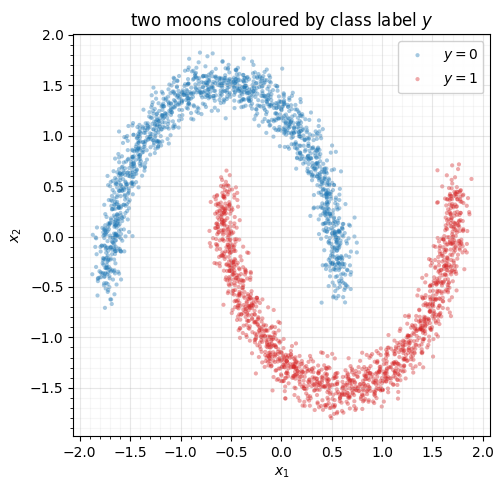

In [2]:
N = 3000
X_raw, y = make_moons(n_samples=N, noise=0.06, random_state=0)
X = jnp.asarray((X_raw - X_raw.mean(0)) / X_raw.std(0))
C = jax.nn.one_hot(jnp.asarray(y), num_classes=2)
COND_DIM, EVENT = 2, (2,)

fig, ax = plt.subplots(figsize=(5.4, 5))
for cls, col in ((0, DATA_COLOR), (1, "tab:red")):
    m = y == cls
    ax.scatter(np.asarray(X[m, 0]), np.asarray(X[m, 1]), s=9, alpha=0.4,
               color=col, edgecolors="none", label=f"$y={cls}$")
ax.set(title="two moons coloured by class label $y$", xlabel="$x_1$", ylabel="$x_2$")
ax.set_aspect("equal"); ax.legend(framealpha=0.9); style_ax(ax)
fig.tight_layout()
print(f"X {X.shape}, context C {C.shape}; per class: {int((y==0).sum())} / {int((y==1).sum())}")

## 2. Four configurations

Each flow is the same chain of four `RQSplineCoupling` layers (rational-quadratic
splines {cite}`durkan2019nsf`, 8 bins) with a fixed `Permute` between them so both
coordinates get transformed. The *only* difference is which slots read $c$:

| flow | base | couplings | can model |
|---|---|---|---|
| none | $\mathcal{N}(0,I)$ | unconditional | the marginal only — ignores $y$ |
| base | $\mathcal{N}(\mu(c),\sigma(c)^2)$ | unconditional | per-class **shift** |
| coupling | $\mathcal{N}(0,I)$ | `cond_dim=2` | per-class **shape** |
| both | $\mathcal{N}(\mu(c),\sigma(c)^2)$ | `cond_dim=2` | both |

In [3]:
N_LAYERS = 4


def make_flow(*, base_cond, coupling_cond, key):
    bkey, *lkeys, pkey = jr.split(key, N_LAYERS + 2)
    base = (ConditionalDiagGaussian(bkey, event_shape=EVENT, cond_shape=(COND_DIM,))
            if base_cond else Normal(jnp.zeros(EVENT)))
    cond_dim = COND_DIM if coupling_cond else None
    perm = jr.permutation(pkey, jnp.arange(EVENT[0]))
    transforms = []
    for i, k in enumerate(lkeys):
        transforms.append(RQSplineCoupling(k, shape=EVENT, n_bins=8, interval=4.0,
                                           cond_dim=cond_dim, nn_width=64, nn_depth=2))
        if i < N_LAYERS - 1:
            transforms.append(Permute(perm))
    return SurVAEFlow(base, transforms)


class Adapter(AbstractDistribution):
    """Wrap SurVAEFlow (log_prob signature x, key, condition) as a flowjax dist."""

    flow: SurVAEFlow
    shape: tuple
    cond_shape: tuple | None

    def __init__(self, flow):
        self.flow, self.shape, self.cond_shape = flow, flow.data_shape, (COND_DIM,)

    def _log_prob(self, x, condition=None):
        return self.flow.log_prob(x, jr.key(0), condition=condition)

    def _sample(self, key, condition=None):
        return self.flow.sample(key, condition=condition)


CONFIGS = [("none", False, False), ("base", True, False),
           ("coupling", False, True), ("both", True, True)]
flows = {name: make_flow(base_cond=b, coupling_cond=c, key=jr.key(11 + i))
         for i, (name, b, c) in enumerate(CONFIGS)}
for name, flow in flows.items():
    n = sum(int(np.prod(p.shape)) for p in jax.tree_util.tree_leaves(eqx.filter(flow, eqx.is_array)))
    print(f"{name:>9s}  params: {n:6d}")

     none  params:  24448
     base  params:  29056
 coupling  params:  24960
     both  params:  29568


## 3. Train all four — same objective, same hyperparameters

Every flow minimises the conditional NLL $-\mathbb{E}_{(x,c)}[\log p(x\mid c)]$ via
the *same* code path; only the layers' `cond_shape`s differ. Two-moons is easy for
spline couplings, so a short run suffices.

     none  stopped at 231 epochs, val NLL +1.3516


     base  stopped at  58 epochs, val NLL +0.9945


 coupling  stopped at 147 epochs, val NLL +0.6180


     both  stopped at 107 epochs, val NLL +0.6152


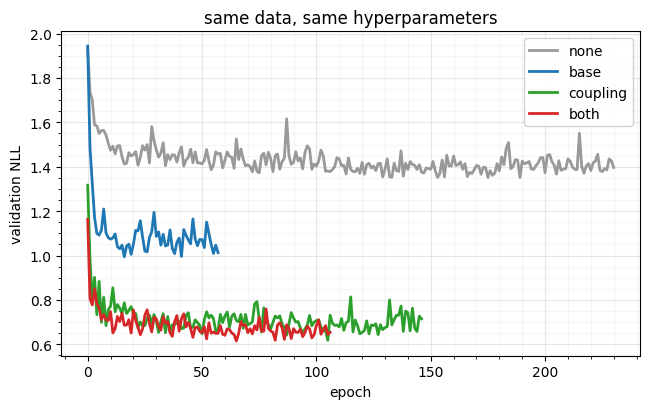

In [4]:
def train(flow, key):
    trained, losses = fit_to_data(key, Adapter(flow), (X, C), learning_rate=5e-3,
                                  max_epochs=300, max_patience=40, batch_size=256,
                                  val_prop=0.1, show_progress=False)
    return trained.flow, losses


trained, losses_all = {}, {}
for i, (name, _, _) in enumerate(CONFIGS):
    trained[name], losses_all[name] = train(flows[name], jr.key(20 + i))
    print(f"{name:>9s}  stopped at {len(losses_all[name]['train']):>3d} epochs, "
          f"val NLL {float(min(losses_all[name]['val'])):+.4f}")

colors = {"none": "0.6", "base": DATA_COLOR, "coupling": "tab:green", "both": "tab:red"}
fig, ax = plt.subplots(figsize=(6.6, 4.2))
for name, _, _ in CONFIGS:
    ax.plot(losses_all[name]["val"], color=colors[name], lw=2, label=name)
ax.set(xlabel="epoch", ylabel="validation NLL", title="same data, same hyperparameters")
ax.legend(framealpha=0.9); style_ax(ax)
fig.tight_layout()

## 4. Per-class samples — does mass land on the right crescent?

Conditional sampling exploits invertibility: $z\sim p_Z(\cdot\mid c)$, then
$x=T^{-1}(z; c)$. For each class we overlay flow samples (one panel per config) on
the true class data. The **none** flow has no label, so it samples the *whole*
two-moons in both rows — half its mass lands in the wrong crescent.

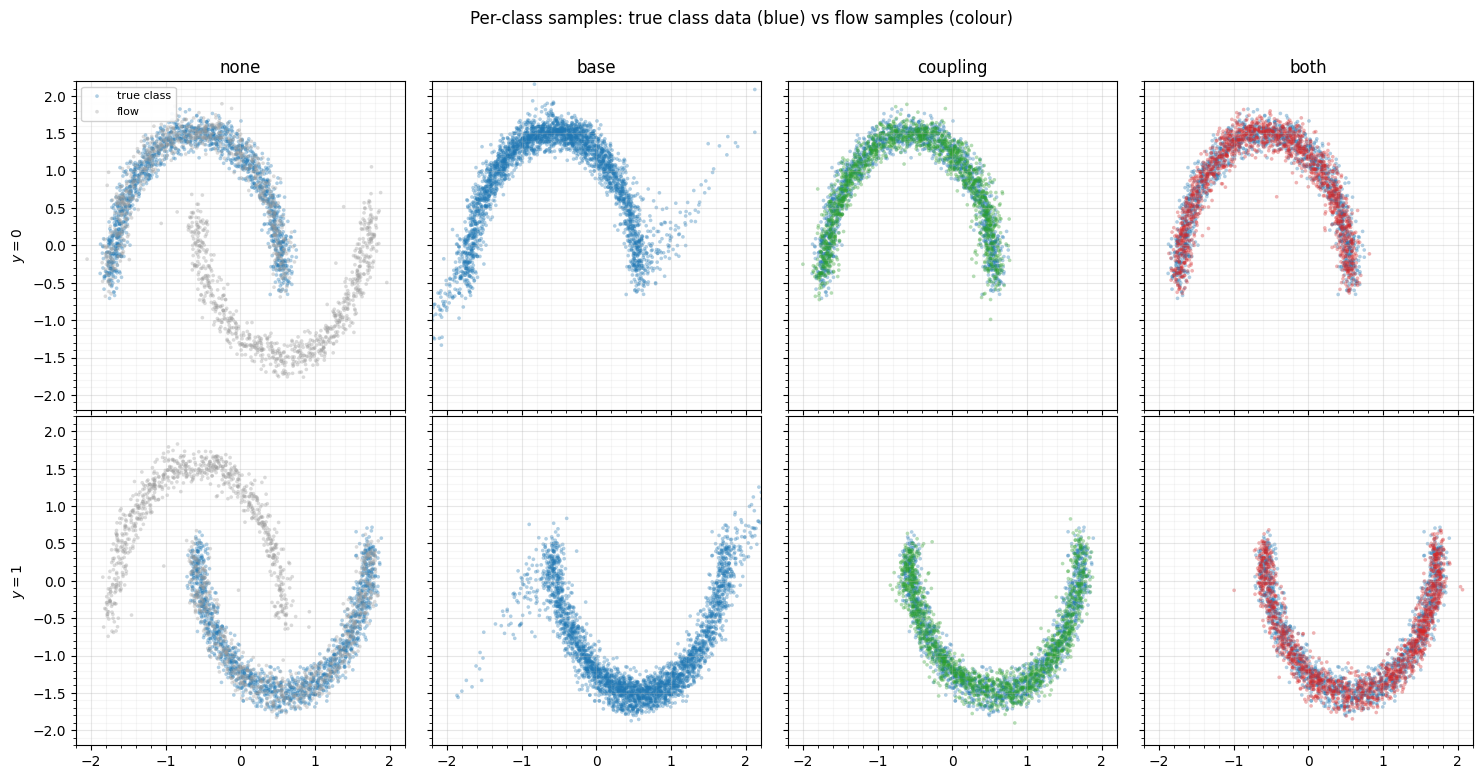

In [5]:
classes = jnp.eye(2)
n_s = 1500


def flow_samples(flow, c, key):
    cond = jnp.broadcast_to(c, (n_s, COND_DIM))
    return jax.vmap(lambda k, ci: flow.sample(k, condition=ci))(jr.split(key, n_s), cond)


fig, axes = plt.subplots(2, 4, figsize=(15, 7.6), sharex=True, sharey=True)
for row, c in enumerate(classes):
    cls = int(jnp.argmax(c))
    true = X[y == cls]
    for col, (name, _, _) in enumerate(CONFIGS):
        ax = axes[row, col]
        s = flow_samples(trained[name], c, jr.fold_in(jr.key(100 + col), row))
        ax.scatter(np.asarray(true[:, 0]), np.asarray(true[:, 1]), s=7, alpha=0.35,
                   color=DATA_COLOR, edgecolors="none", label="true class")
        ax.scatter(np.asarray(s[:, 0]), np.asarray(s[:, 1]), s=7, alpha=0.35,
                   color=colors[name], edgecolors="none", label="flow")
        ax.set(xlim=(-2.2, 2.2), ylim=(-2.2, 2.2))
        ax.set_aspect("equal"); style_ax(ax)
        if row == 0:
            ax.set_title(name)
        if col == 0:
            ax.set_ylabel(f"$y={cls}$")
    if row == 0:
        axes[0, 0].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle("Per-class samples: true class data (blue) vs flow samples (colour)", y=1.01)
fig.tight_layout()

## 5. Conditional log-likelihood ranking

The mean conditional log-likelihood $\frac1N\sum_n \log p(x_n\mid c_n)$ ranks the
four — higher is better.

In [6]:
def mean_lp(flow):
    f = eqx.filter_jit(lambda x, c: jax.vmap(lambda xi, ci: flow.log_prob(xi, jr.key(0), condition=ci))(x, c))
    return float(jnp.mean(f(X, C)))


print("mean conditional log-likelihood (higher is better):")
for name, _, _ in CONFIGS:
    print(f"  {name:>9s}: {mean_lp(trained[name]):+.4f}")

mean conditional log-likelihood (higher is better):


       none: -1.3208


       base: -0.9986


   coupling: -0.6282


       both: -0.6290


## Recap — where to put the context

| if $y$ changes... | condition the... | why |
|---|---|---|
| only the **location / scale** of $p(x\mid y)$ | **base** | one Gaussian per context, cheap |
| the **shape** of $p(x\mid y)$ | **couplings** (`cond_dim`) | per-context map, $K$-fold capacity |
| a transform that can't read $y$ (rotation, norm) | wrap in **`Conditioner`** | FiLM modulation, keeps log-det closed-form |

The ranking tells the story: **none** ignores $y$ and pays for it; **base-only**
fixes the per-class *position* but shares one crescent shape; **coupling** (and
**both**) read the label inside the splines and produce genuinely class-specific
crescents, so they win. Here the classes differ in shape, so the couplings carry the
conditioning — but the principle is the headline of Part 7: **decide, per slot,
whether it should see $y$**, and the same $y$ threads through.

**Next up.** [01 — Conditional marginals & density estimation](01_conditional_density.ipynb)
moves to a *continuous* context and a $y$-dependent CDF, and checks that $p(x\mid y)$
is calibrated — including the Gaussianization-direction view this notebook left implicit.